In [76]:
# Importing necessary libraries

import pandas as pd
import re
import random

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.util import bigrams

import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

In [77]:
# Loading the dataset

df = pd.read_csv('../data/mental_health.csv', index_col=0)
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [78]:
# Display the first few rows of the dataframe

df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [79]:
# Display summary statistics of the dataframe

df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [80]:
# Display information about the dataframe

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 828.9 KB


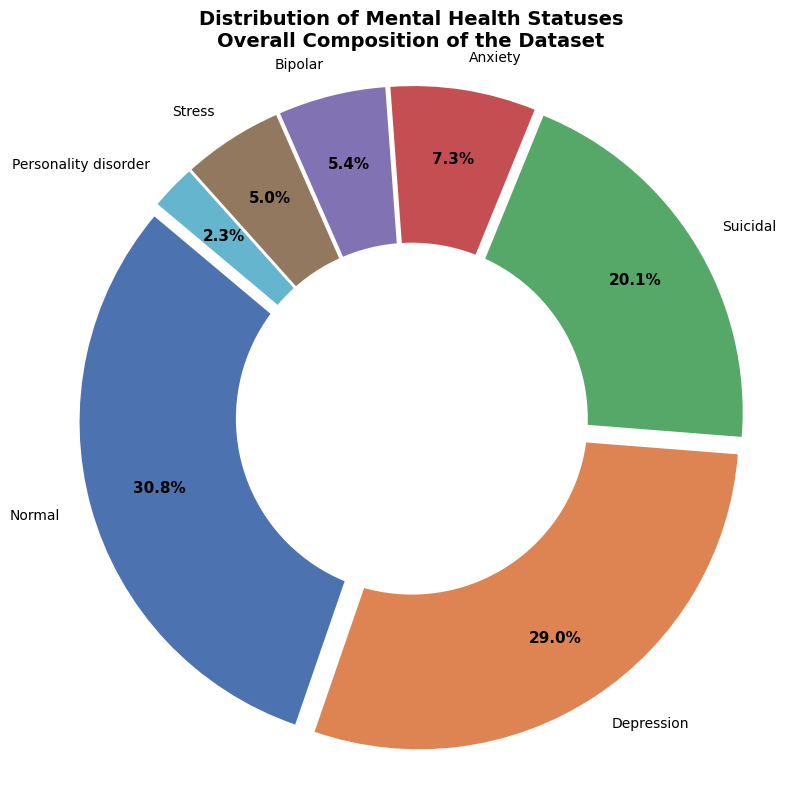

In [81]:
# Visualizing the distribution of mental health statuses

status_counts = df['status'].value_counts()

colors = [
    '#4C72B0',  # blue
    '#DD8452',  # orange
    '#55A868',  # green
    '#C44E52',  # red
    '#8172B3',  # purple
    '#937860',  # brown
    '#64B5CD'   # cyan
]

explode = [0.04] * len(status_counts)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.78,
    shadow=False
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

plt.title(
    'Distribution of Mental Health Statuses\n'
    'Overall Composition of the Dataset',
    fontsize=14,
    weight='bold'
)

plt.axis('equal')
plt.tight_layout()
plt.show()

In [82]:
# Checking for missing values in the dataframe

df.isna().sum()

statement    362
status         0
dtype: int64

In [83]:
# Dropping rows with missing values and checking again for missing values

df.dropna(inplace = True)
df.isna().sum()

statement    0
status       0
dtype: int64

In [84]:
# Selecting a random statement for each mental health status

random_statements = df.groupby('status')['statement'].apply(lambda x: x.sample(n=1).iloc[0])

# Printing the results

for status, statement in random_statements.items():
    print(f"Status: {status}")
    print(f"Statement: {statement}\n")

Status: Anxiety
Statement: How do you deal with the anxiety of having a crush on someone or starting a new relationship I over think and catastrophisize everything so much. I end up ruining everything. Any tips? Or any experiences you guys want to share?

Status: Bipolar
Statement: How do I make friends as someone with bipolar/social anxiety? I've never really had a best friend, and at most I've had like 2-3 good friends and then a bunch of people who I'm friendly with but would never interact with outside of school (college). I'm worried my bipolar is scaring people away. I feel like even thought most people don't know i have bipolar they know something is wrong with me it drives them away. I'm eccentric, show up having a completely different mood than the day before...typical bipolar stuff and I just feel like people know I'm not right. or maybe there's other reasons I'm not good at having best friends. Out of my two closest friends, I guarantee I am in neithers top 3, top 5 maybe no

In [85]:
# Analyzing the length of statements

df['num_of_characters'] = df['statement'].str.len()
df['num_of_sentences'] = df['statement'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Displaying descriptive statistics for the new columns

description = df[['num_of_characters', 'num_of_sentences']].describe()
description

,num_of_characters,num_of_sentences
count,52681.000000,52681.000000
mean,578.713863,6.280215
std,846.269078,10.688388
min,2.000000,1.000000
25%,80.000000,1.000000
50%,317.000000,3.000000
75%,752.000000,8.000000
max,32759.000000,1260.000000


In [86]:
# Displaying the entire data with new columns (num_of_characters, num_of_sentences)

df

,statement,status,num_of_characters,num_of_sentences
0,oh my gosh,Anxiety,10,1
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,2
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,2
3,I've shifted my focus to something else but I'...,Anxiety,61,1
4,"I'm restless and restless, it's been a month n...",Anxiety,72,2
...,...,...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety,1766,16
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety,1012,12
53040,Is there any way to sleep better? I can't slee...,Anxiety,85,2
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety,401,6


In [87]:
# Converting all statements to lowercase to ensure uniformity

df['statement']=df['statement'].str.lower()
df

,statement,status,num_of_characters,num_of_sentences
0,oh my gosh,Anxiety,10,1
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,2
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety,78,2
3,i've shifted my focus to something else but i'...,Anxiety,61,1
4,"i'm restless and restless, it's been a month n...",Anxiety,72,2
...,...,...,...,...
53038,nobody takes me seriously i’ve (24m) dealt wit...,Anxiety,1766,16
53039,"selfishness ""i don't feel very good, it's lik...",Anxiety,1012,12
53040,is there any way to sleep better? i can't slee...,Anxiety,85,2
53041,"public speaking tips? hi, all. i have to give ...",Anxiety,401,6


In [88]:
# Function to remove URLs, markdown links, handles, and special characters

def remove_patterns(text):
    # Removing URLs
    text = re.sub(r'http[s]?://\S+', '', text)
    # Removing markdown-style links
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)
    # Removing handles (that start with '@')
    text = re.sub(r'@\w+', '', text)
    # Removing punctuation and other special characters
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

In [89]:
# Applying the function to the 'statement' column

df['statement'] = df['statement'].apply(remove_patterns)
df

,statement,status,num_of_characters,num_of_sentences
0,oh my gosh,Anxiety,10,1
1,trouble sleeping confused mind restless heart ...,Anxiety,64,2
2,all wrong back off dear forward doubt stay in ...,Anxiety,78,2
3,ive shifted my focus to something else but im ...,Anxiety,61,1
4,im restless and restless its been a month now ...,Anxiety,72,2
...,...,...,...,...
53038,nobody takes me seriously ive 24m dealt with d...,Anxiety,1766,16
53039,selfishness i dont feel very good its like i ...,Anxiety,1012,12
53040,is there any way to sleep better i cant sleep ...,Anxiety,85,2
53041,public speaking tips hi all i have to give a p...,Anxiety,401,6


In [90]:
# Applying  word_tokenize to each element in the 'statement' column

df['tokens'] = df['statement'].apply(word_tokenize)
df

,statement,status,num_of_characters,num_of_sentences,tokens
0,oh my gosh,Anxiety,10,1,"[oh, my, gosh]"
1,trouble sleeping confused mind restless heart ...,Anxiety,64,2,"[trouble, sleeping, confused, mind, restless, ..."
2,all wrong back off dear forward doubt stay in ...,Anxiety,78,2,"[all, wrong, back, off, dear, forward, doubt, ..."
3,ive shifted my focus to something else but im ...,Anxiety,61,1,"[ive, shifted, my, focus, to, something, else,..."
4,im restless and restless its been a month now ...,Anxiety,72,2,"[im, restless, and, restless, its, been, a, mo..."
...,...,...,...,...,...
53038,nobody takes me seriously ive 24m dealt with d...,Anxiety,1766,16,"[nobody, takes, me, seriously, ive, 24m, dealt..."
53039,selfishness i dont feel very good its like i ...,Anxiety,1012,12,"[selfishness, i, dont, feel, very, good, its, ..."
53040,is there any way to sleep better i cant sleep ...,Anxiety,85,2,"[is, there, any, way, to, sleep, better, i, ca..."
53041,public speaking tips hi all i have to give a p...,Anxiety,401,6,"[public, speaking, tips, hi, all, i, have, to,..."


In [91]:
# Initializing the Porter Stemmer
stemmer = PorterStemmer()

# Function to stem tokens and convert them to strings
def stem_tokens(tokens):
    return ' '.join(stemmer.stem(str(token)) for token in tokens)

In [92]:
# Applying the function to the 'tokens' column

df['tokens_stemmed'] = df['tokens'].apply(stem_tokens)
df

,statement,status,num_of_characters,num_of_sentences,tokens,tokens_stemmed
0,oh my gosh,Anxiety,10,1,"[oh, my, gosh]",oh my gosh
1,trouble sleeping confused mind restless heart ...,Anxiety,64,2,"[trouble, sleeping, confused, mind, restless, ...",troubl sleep confus mind restless heart all ou...
2,all wrong back off dear forward doubt stay in ...,Anxiety,78,2,"[all, wrong, back, off, dear, forward, doubt, ...",all wrong back off dear forward doubt stay in ...
3,ive shifted my focus to something else but im ...,Anxiety,61,1,"[ive, shifted, my, focus, to, something, else,...",ive shift my focu to someth els but im still w...
4,im restless and restless its been a month now ...,Anxiety,72,2,"[im, restless, and, restless, its, been, a, mo...",im restless and restless it been a month now b...
...,...,...,...,...,...,...
53038,nobody takes me seriously ive 24m dealt with d...,Anxiety,1766,16,"[nobody, takes, me, seriously, ive, 24m, dealt...",nobodi take me serious ive 24m dealt with depr...
53039,selfishness i dont feel very good its like i ...,Anxiety,1012,12,"[selfishness, i, dont, feel, very, good, its, ...",selfish i dont feel veri good it like i dont b...
53040,is there any way to sleep better i cant sleep ...,Anxiety,85,2,"[is, there, any, way, to, sleep, better, i, ca...",is there ani way to sleep better i cant sleep ...
53041,public speaking tips hi all i have to give a p...,Anxiety,401,6,"[public, speaking, tips, hi, all, i, have, to,...",public speak tip hi all i have to give a prese...


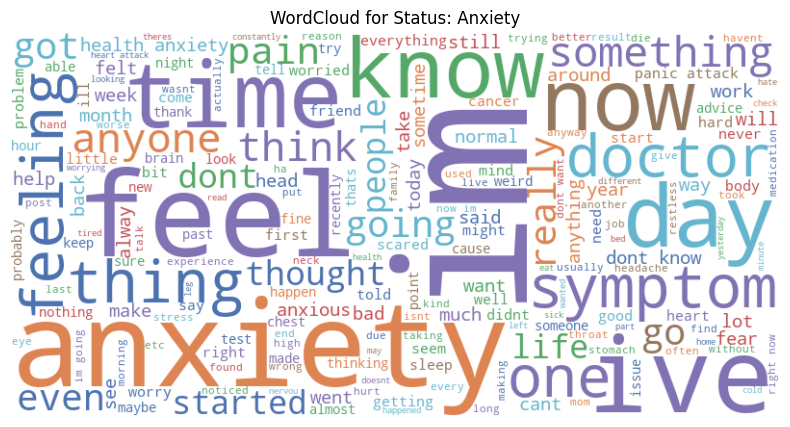

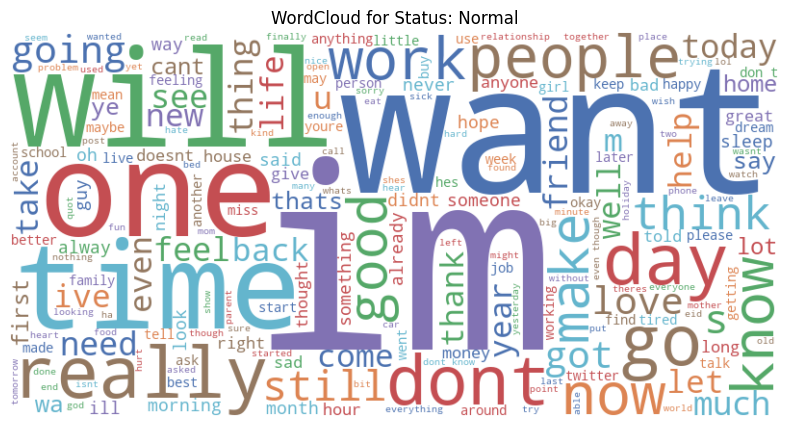

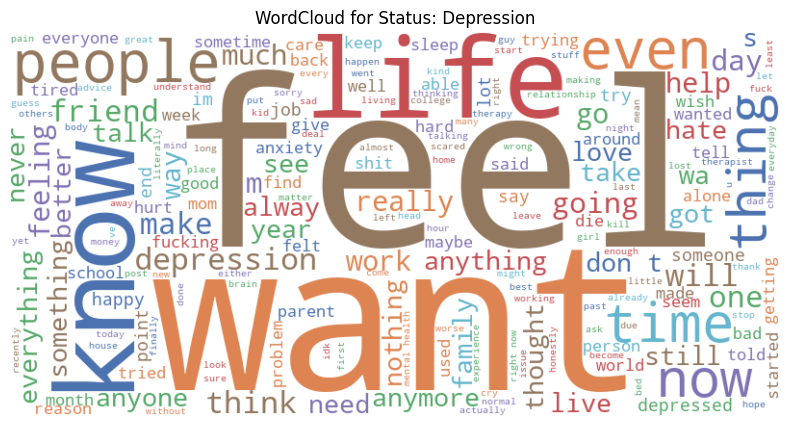

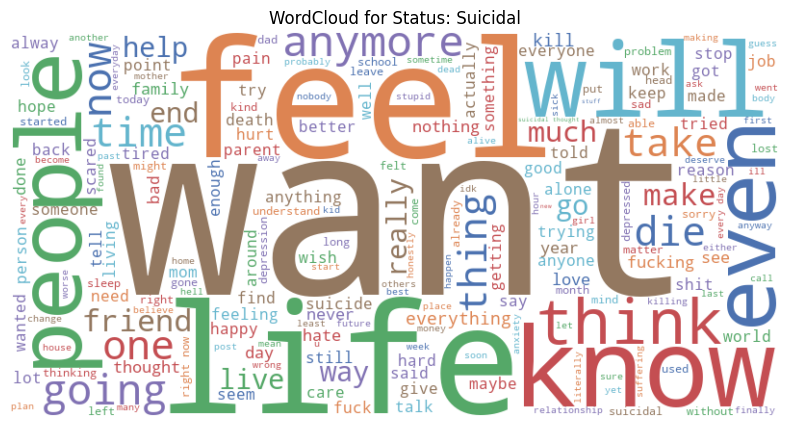

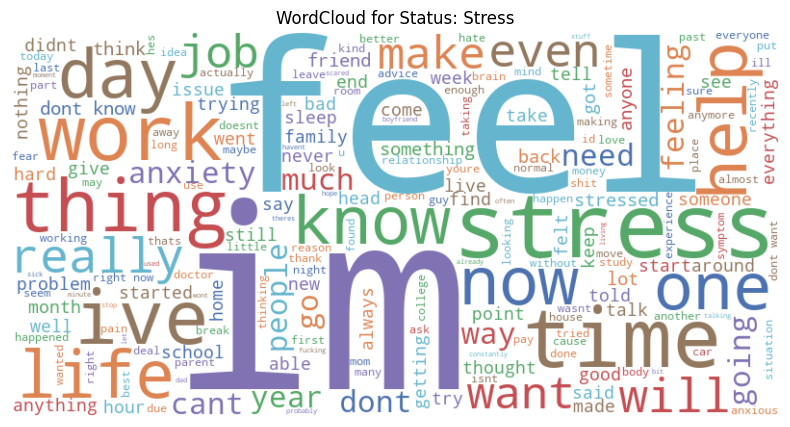

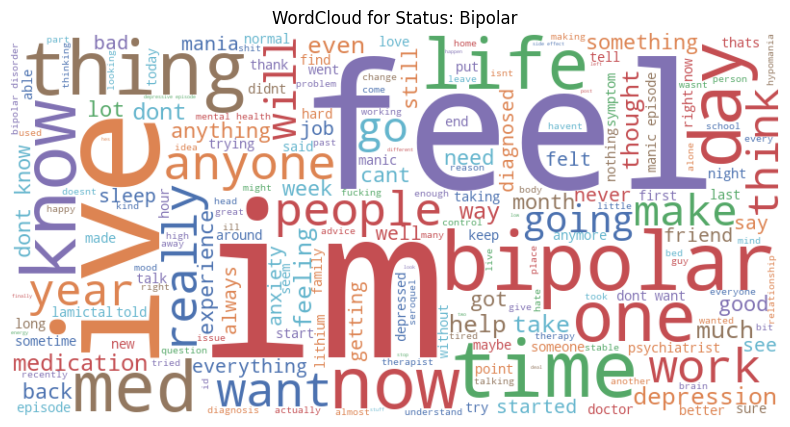

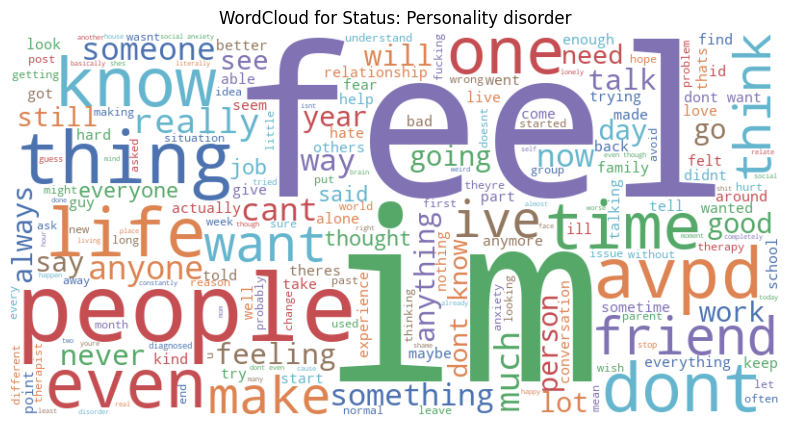

In [93]:
statuses = df['status'].unique()

# Defining a color function
def color_func(word, font_size, position, orientation, random_state=101, **kwargs):
    return random.choice(colors)

# Generating and plot the WordCloud for each category
for status in statuses:
    # Filtering the tokens data for the current status
    tokens_data = ' '.join(df[df['status'] == status]['tokens'].dropna().apply(lambda x: ' '.join(x)).tolist())

    # Generating the WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(tokens_data)
    
    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axis
    plt.title(f'WordCloud for Status: {status}')
    plt.show()

In [94]:
# Function to create bigrams from tokens

def make_bigrams(tokens):
    return ['_'.join(bg) for bg in bigrams(tokens)]

In [95]:
# Creating bigrams and adding them to a new column

df['bigrams'] = df['tokens'].dropna().apply(make_bigrams)
df

,statement,status,num_of_characters,num_of_sentences,tokens,tokens_stemmed,bigrams
0,oh my gosh,Anxiety,10,1,"[oh, my, gosh]",oh my gosh,"[oh_my, my_gosh]"
1,trouble sleeping confused mind restless heart ...,Anxiety,64,2,"[trouble, sleeping, confused, mind, restless, ...",troubl sleep confus mind restless heart all ou...,"[trouble_sleeping, sleeping_confused, confused..."
2,all wrong back off dear forward doubt stay in ...,Anxiety,78,2,"[all, wrong, back, off, dear, forward, doubt, ...",all wrong back off dear forward doubt stay in ...,"[all_wrong, wrong_back, back_off, off_dear, de..."
3,ive shifted my focus to something else but im ...,Anxiety,61,1,"[ive, shifted, my, focus, to, something, else,...",ive shift my focu to someth els but im still w...,"[ive_shifted, shifted_my, my_focus, focus_to, ..."
4,im restless and restless its been a month now ...,Anxiety,72,2,"[im, restless, and, restless, its, been, a, mo...",im restless and restless it been a month now b...,"[im_restless, restless_and, and_restless, rest..."
...,...,...,...,...,...,...,...
53038,nobody takes me seriously ive 24m dealt with d...,Anxiety,1766,16,"[nobody, takes, me, seriously, ive, 24m, dealt...",nobodi take me serious ive 24m dealt with depr...,"[nobody_takes, takes_me, me_seriously, serious..."
53039,selfishness i dont feel very good its like i ...,Anxiety,1012,12,"[selfishness, i, dont, feel, very, good, its, ...",selfish i dont feel veri good it like i dont b...,"[selfishness_i, i_dont, dont_feel, feel_very, ..."
53040,is there any way to sleep better i cant sleep ...,Anxiety,85,2,"[is, there, any, way, to, sleep, better, i, ca...",is there ani way to sleep better i cant sleep ...,"[is_there, there_any, any_way, way_to, to_slee..."
53041,public speaking tips hi all i have to give a p...,Anxiety,401,6,"[public, speaking, tips, hi, all, i, have, to,...",public speak tip hi all i have to give a prese...,"[public_speaking, speaking_tips, tips_hi, hi_a..."


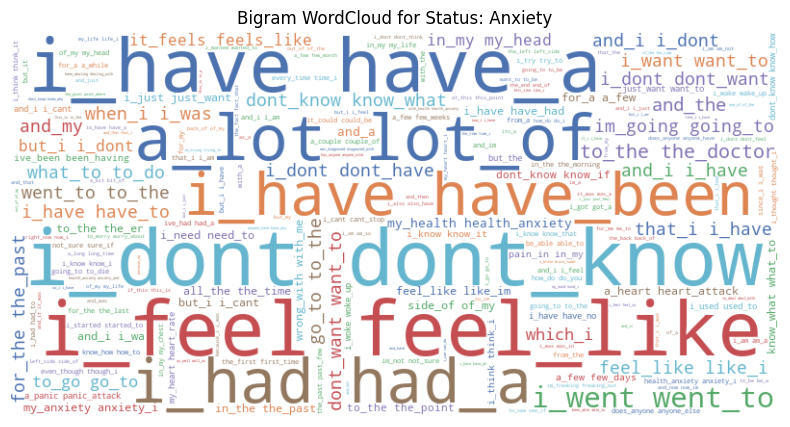

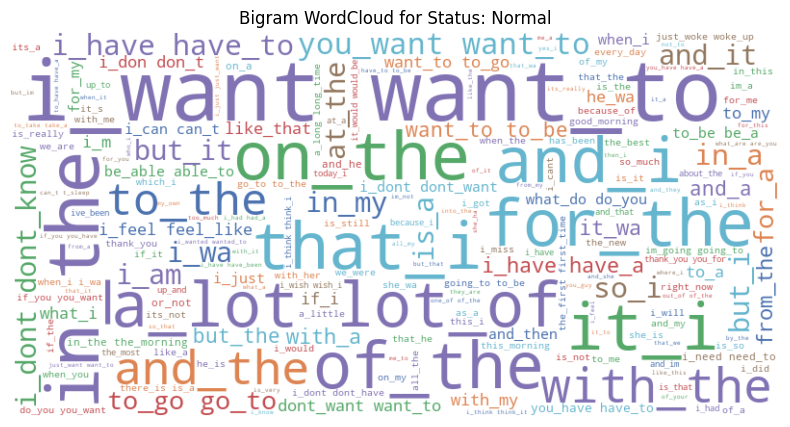

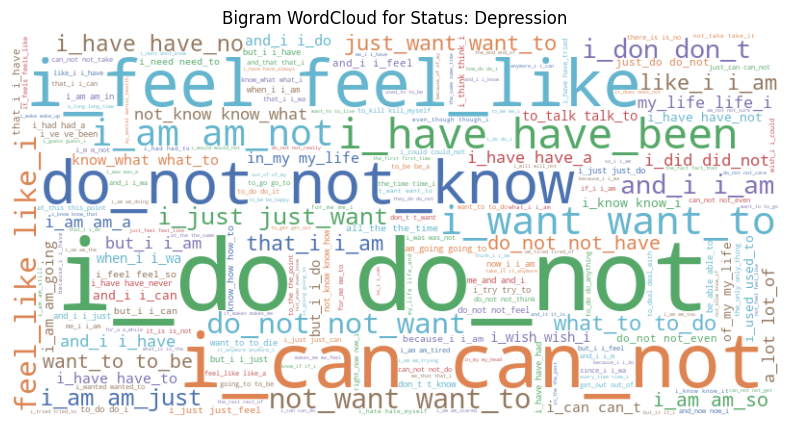

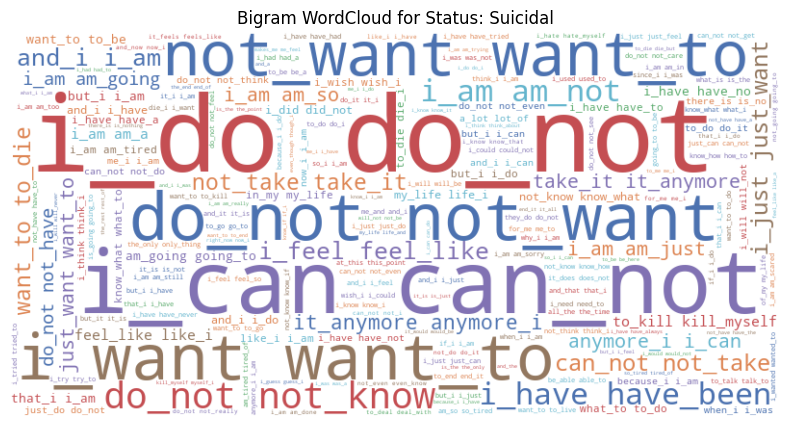

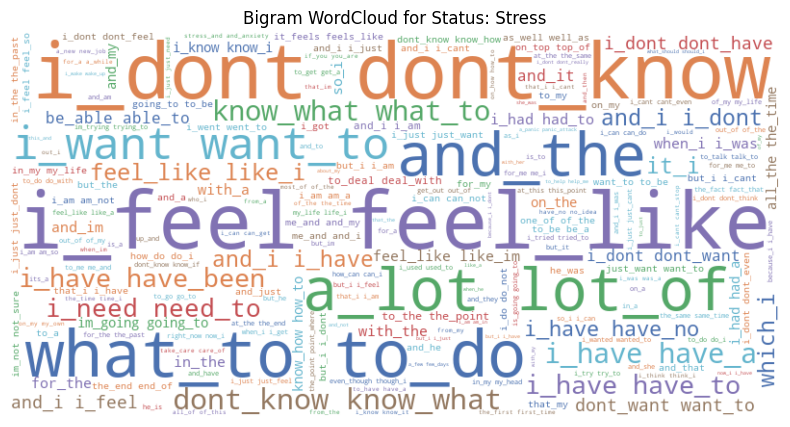

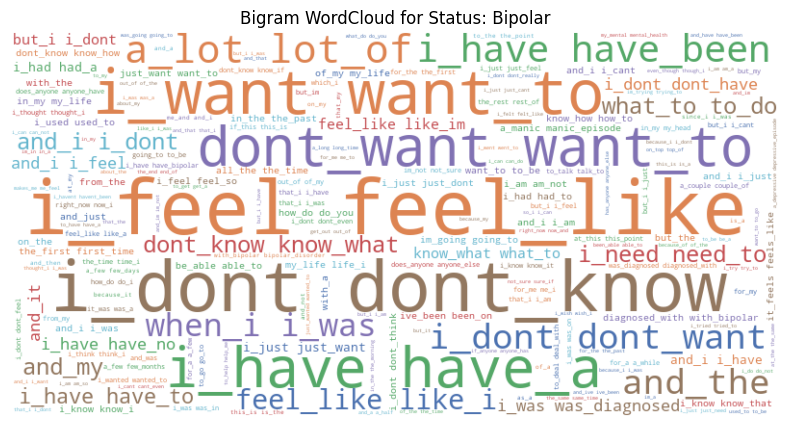

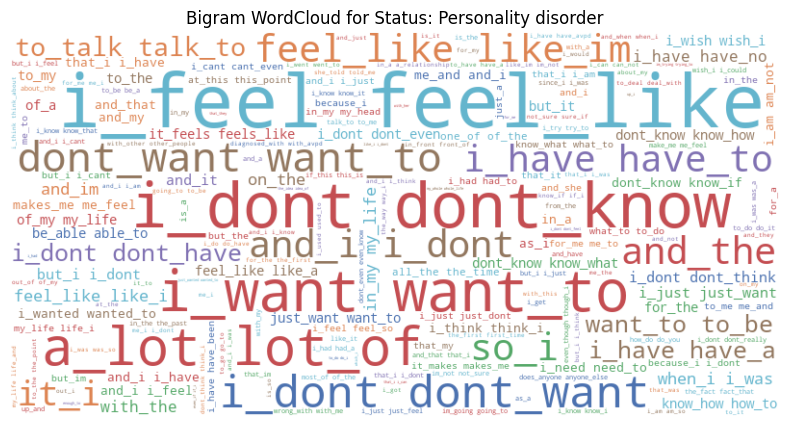

In [96]:
# Generating and plot the Bigram WordCloud for each category

for status in statuses:
    # Filter bigrams for current status
    phrases_data = ' '.join(
        df[df['status'] == status]['bigrams']
        .dropna()
        .apply(lambda x: ' '.join(x))
        .tolist()
    )

    # Generate WordCloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        color_func=color_func
    ).generate(phrases_data)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Bigram WordCloud for Status: {status}')
    plt.show()

In [97]:
# Splitting the dataset into training and testing sets

X = df['tokens_stemmed']
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [98]:
# Encoding the target labels

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [99]:
# Encoding the text data using TF-IDF Vectorization

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50000) 

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [100]:
# Training a Logistic Regression model

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [101]:
# Making predictions on the test set

y_pred = log_reg.predict(X_test)

In [102]:
# Evaluating the model's performance

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.7765967542943912

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.80      0.83      0.82       768
             Bipolar       0.76      0.83      0.79       556
          Depression       0.80      0.63      0.70      3081
              Normal       0.89      0.92      0.91      3269
Personality disorder       0.58      0.76      0.66       215
              Stress       0.54      0.74      0.62       517
            Suicidal       0.68      0.74      0.71      2131

            accuracy                           0.78     10537
           macro avg       0.72      0.78      0.74     10537
        weighted avg       0.78      0.78      0.78     10537



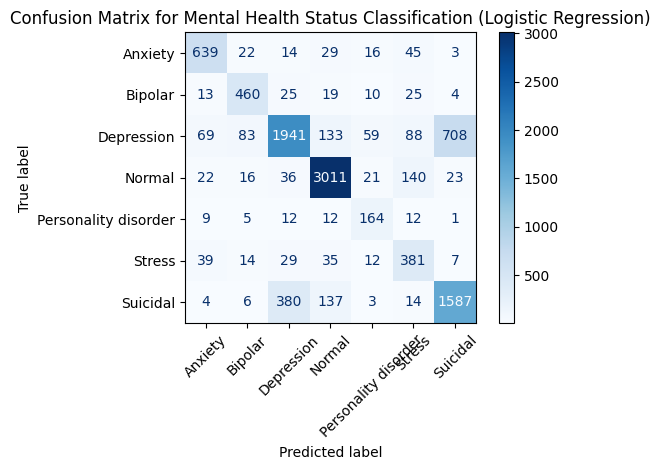

In [103]:
# Visualizing the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix for Mental Health Status Classification (Logistic Regression)")
plt.tight_layout()
plt.show()

In [104]:
# Training a Multinomial Naive Bayes model

nb = MultinomialNB(fit_prior=False, alpha=0.5)
nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.5
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",False
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [105]:
# Making predictions on the test set

y_pred_nb = nb.predict(X_test)

In [106]:
# Evaluating the model's performance

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

Accuracy: 0.6964980544747081

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.60      0.76      0.67       768
             Bipolar       0.70      0.67      0.69       556
          Depression       0.61      0.70      0.65      3081
              Normal       0.90      0.76      0.82      3269
Personality disorder       0.82      0.14      0.25       215
              Stress       0.60      0.27      0.37       517
            Suicidal       0.64      0.74      0.69      2131

            accuracy                           0.70     10537
           macro avg       0.70      0.58      0.59     10537
        weighted avg       0.71      0.70      0.69     10537



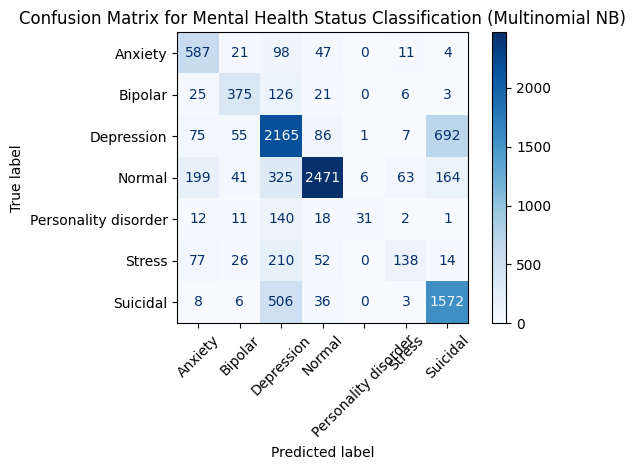

In [107]:
# Visualizing the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_nb),
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix for Mental Health Status Classification (Multinomial NB)")
plt.tight_layout()
plt.show()

In [108]:
# Training an XGBoost Classifier

xgboost = XGBClassifier(
    tree_method="hist",      
    learning_rate=0.1,
    max_depth=5,             
    n_estimators=150,        
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss"
)
xgboost.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [109]:
# Making predictions on the test set

y_pred_xg = xgboost.predict(X_test)

In [110]:
# Evaluating the model's performance

print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xg, target_names=label_encoder.classes_))

Accuracy: 0.7717566669830123

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.80      0.76      0.78       768
             Bipolar       0.89      0.73      0.80       556
          Depression       0.72      0.74      0.73      3081
              Normal       0.85      0.95      0.89      3269
Personality disorder       0.86      0.62      0.72       215
              Stress       0.63      0.54      0.58       517
            Suicidal       0.70      0.64      0.67      2131

            accuracy                           0.77     10537
           macro avg       0.78      0.71      0.74     10537
        weighted avg       0.77      0.77      0.77     10537



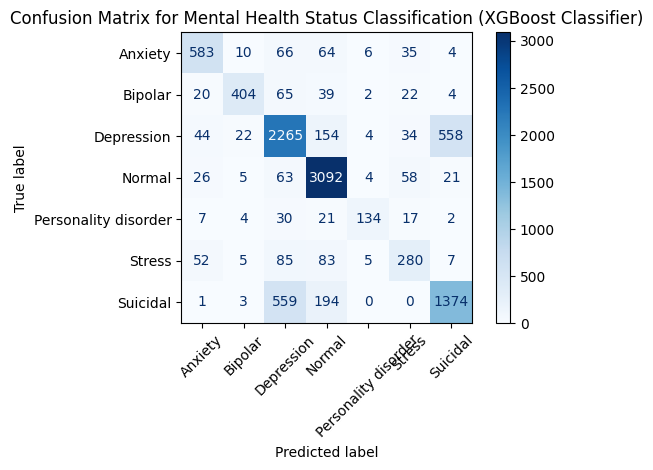

In [111]:
# Visualizing the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xg),
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix for Mental Health Status Classification (XGBoost Classifier)")
plt.tight_layout()
plt.show()